Mokymo kainų periodas:
2020-01-02 00:00:00 iki 2023-12-29 00:00:00

Testavimo kainų periodas:
2024-01-02 00:00:00 iki 2025-12-31 00:00:00

Mokymo kainų duomenų forma: (1006, 10)
Testavimo kainų duomenų forma: (502, 10)

Mokymo grąžų forma: (1005, 10)
Testavimo grąžų forma: (501, 10)

Mokymo laikotarpio trūkstamos reikšmės:
Ticker
AAPL    0
CAT     0
JNJ     0
JPM     0
KO      0
MSFT    0
PG      0
V       0
WMT     0
XOM     0
dtype: int64

Testavimo laikotarpio trūkstamos reikšmės:
Ticker
AAPL    0
CAT     0
JNJ     0
JPM     0
KO      0
MSFT    0
PG      0
V       0
WMT     0
XOM     0
dtype: int64

Mokymo laikotarpio akcijų suvestinė:
        Metinė vidutinė grąža  Metinė rizika
Ticker                                      
XOM                  0.207865       0.372290
JPM                  0.136226       0.344239
CAT                  0.250556       0.339306
AAPL                 0.299015       0.335681
MSFT                 0.275846       0.326155
V                    0.129395       0.

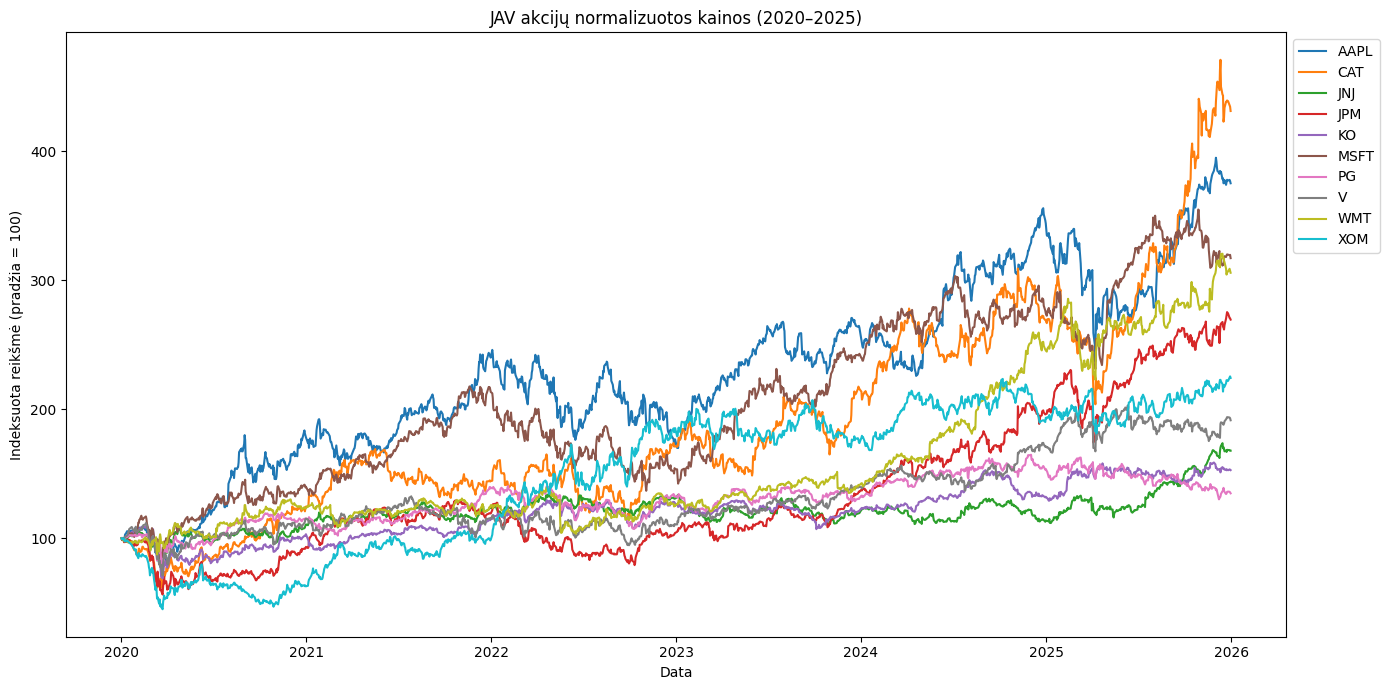

In [ ]:
import warnings
warnings.filterwarnings(
    "ignore",
    message=r".*Timestamp\.utcnow is deprecated.*"
)
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# atsiunčiamos akcijos
akcijos = ['AAPL','MSFT','JPM','JNJ','XOM','WMT','PG','CAT','V','KO']
kainos = yf.download(
    akcijos,
    start="2020-01-01",
    end="2026-01-01",
    auto_adjust=True,
    progress=False
)["Close"]
# duomenu patikrinimas ir paruošimas
kainos = kainos.dropna(how="all")
kainos = kainos.dropna()
kainos_mokymui = kainos.loc["2020-01-01":"2023-12-31"]
kainos_testavimui = kainos.loc["2024-01-01":"2025-12-31"]
grąžos_mokymui = kainos_mokymui.pct_change().dropna()
grąžos_testavimui = kainos_testavimui.pct_change().dropna()
print("Mokymo kainų periodas:")
print(kainos_mokymui.index.min(), "iki", kainos_mokymui.index.max())
print("\nTestavimo kainų periodas:")
print(kainos_testavimui.index.min(), "iki", kainos_testavimui.index.max())
print("\nMokymo kainų duomenų forma:", kainos_mokymui.shape)
print("Testavimo kainų duomenų forma:", kainos_testavimui.shape)
print("\nMokymo grąžų forma:", grąžos_mokymui.shape)
print("Testavimo grąžų forma:", grąžos_testavimui.shape)
print("\nMokymo laikotarpio trūkstamos reikšmės:")
print(kainos_mokymui.isna().sum())
print("\nTestavimo laikotarpio trūkstamos reikšmės:")
print(kainos_testavimui.isna().sum())
vidutinė_metinė_grąža = grąžos_mokymui.mean() * 252
metinė_rizika = grąžos_mokymui.std() * np.sqrt(252)
suvestinė = pd.DataFrame({
    "Metinė vidutinė grąža": vidutinė_metinė_grąža,
    "Metinė rizika": metinė_rizika
})
print("\nMokymo laikotarpio akcijų suvestinė:")
print(suvestinė.sort_values("Metinė rizika", ascending=False))
normalizuotos_kainos = kainos / kainos.iloc[0] * 100
plt.figure(figsize=(14, 7))
for stulpelis in normalizuotos_kainos.columns:
    plt.plot(normalizuotos_kainos.index, normalizuotos_kainos[stulpelis], label=stulpelis)
plt.title("JAV akcijų normalizuotos kainos (2020–2025)")
plt.xlabel("Data")
plt.ylabel("Indeksuota reikšmė (pradžia = 100)")
plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

In [21]:
from scipy.optimize import minimize
import numpy as np
import pandas as pd

nerizikinga_palukanu_norma = 0.0
vidutines_metines_grazos = grąžos_mokymui.mean() * 252
kovariaciju_matrica = grąžos_mokymui.cov() * 252

def portfelio_rodikliai(svoriai, vidutines_metines_grazos, kovariaciju_matrica):
    portfelio_graza = np.sum(svoriai * vidutines_metines_grazos)
    portfelio_rizika = np.sqrt(np.dot(svoriai.T, np.dot(kovariaciju_matrica, svoriai)))
    return portfelio_graza, portfelio_rizika

def neigiamas_sharpe_rodiklis(svoriai, vidutines_metines_grazos, kovariaciju_matrica, nerizikinga_palukanu_norma):
    portfelio_graza, portfelio_rizika = portfelio_rodikliai(svoriai, vidutines_metines_grazos, kovariaciju_matrica)
    if portfelio_rizika == 0:
        return 1e6
    return -((portfelio_graza - nerizikinga_palukanu_norma) / portfelio_rizika)

akciju_skaicius = grąžos_mokymui.shape[1]

pradiniai_svoriai = np.repeat(1 / akciju_skaicius, akciju_skaicius)

apribojimai = ({
    'type': 'eq',
    'fun': lambda svoriai: np.sum(svoriai) - 1
})

ribos = tuple((0, 1) for _ in range(akciju_skaicius))

optimizavimo_rezultatas = minimize(
    neigiamas_sharpe_rodiklis,
    pradiniai_svoriai,
    args=(vidutines_metines_grazos, kovariaciju_matrica, nerizikinga_palukanu_norma),
    method='SLSQP',
    bounds=ribos,
    constraints=apribojimai
)
svoriai_maksimaliam_sharpe = optimizavimo_rezultatas.x.copy()
paklaidos_riba = 1e-10
svoriai_maksimaliam_sharpe[np.abs(svoriai_maksimaliam_sharpe) < paklaidos_riba] = 0
svoriai_maksimaliam_sharpe = svoriai_maksimaliam_sharpe / svoriai_maksimaliam_sharpe.sum()
maksimali_sharpe_graza, maksimali_sharpe_rizika = portfelio_rodikliai(
    svoriai_maksimaliam_sharpe, vidutines_metines_grazos, kovariaciju_matrica
)
maksimalus_sharpe_rodiklis = (maksimali_sharpe_graza - nerizikinga_palukanu_norma) / maksimali_sharpe_rizika
maksimalaus_sharpe_svoriu_lentele = pd.DataFrame({
    "Akcija": grąžos_mokymui.columns,
    "Svoris": svoriai_maksimaliam_sharpe,
    "Svoris_proc": svoriai_maksimaliam_sharpe * 100
})
maksimalaus_sharpe_svoriu_lentele["Svoris"] = maksimalaus_sharpe_svoriu_lentele["Svoris"].round(4)
maksimalaus_sharpe_svoriu_lentele["Svoris_proc"] = maksimalaus_sharpe_svoriu_lentele["Svoris_proc"].round(2)
maksimalaus_sharpe_svoriu_lentele = maksimalaus_sharpe_svoriu_lentele.sort_values("Svoris", ascending=False).reset_index(drop=True)
print("Maksimalaus Sharpe rodiklio portfelio svoriai:")
print(maksimalaus_sharpe_svoriu_lentele.to_string(index=False))
print("\nSvorių suma:", round(svoriai_maksimaliam_sharpe.sum(), 6))
print("Metinė tikėtina grąža:", round(maksimali_sharpe_graza, 4))
print("Metinė rizika:", round(maksimali_sharpe_rizika, 4))
print("Sharpe rodiklis:", round(maksimalus_sharpe_rodiklis, 4))

Maksimalaus Sharpe rodiklio portfelio svoriai:
Akcija  Svoris  Svoris_proc
  AAPL  0.3467        34.67
   CAT  0.2977        29.77
  MSFT  0.2373        23.73
   WMT  0.0661         6.61
   XOM  0.0522         5.22
   JNJ  0.0000         0.00
    KO  0.0000         0.00
   JPM  0.0000         0.00
     V  0.0000         0.00
    PG  0.0000         0.00

Svorių suma: 1.0
Metinė tikėtina grąža: 0.2621
Metinė rizika: 0.2582
Sharpe rodiklis: 1.0152


In [15]:
akciju_skaicius = grąžos_mokymui.shape[1]
vienodi_svoriai = np.repeat(1 / akciju_skaicius, akciju_skaicius)
vienodu_svoriu_lentele = pd.DataFrame({
    "Akcija": grąžos_mokymui.columns,
    "Svoris": vienodi_svoriai,
    "Svoris_proc": vienodi_svoriai * 100
})

vienodu_svoriu_lentele["Svoris"] = vienodu_svoriu_lentele["Svoris"].round(4)
vienodu_svoriu_lentele["Svoris_proc"] = vienodu_svoriu_lentele["Svoris_proc"].round(2)
vienodu_svoriu_lentele = vienodu_svoriu_lentele.sort_values("Svoris", ascending=False).reset_index(drop=True)
vienodu_svoriu_graza, vienodu_svoriu_rizika = portfelio_rodikliai(
    vienodi_svoriai, vidutines_metines_grazos, kovariaciju_matrica
)
vienodu_svoriu_sharpe_rodiklis = (vienodu_svoriu_graza - nerizikinga_palukanu_norma) / vienodu_svoriu_rizika
print("Vienodų svorių portfelio svoriai:")
print(vienodu_svoriu_lentele.to_string(index=False))
print("\nSvorių suma:", round(vienodi_svoriai.sum(), 6))
print("Metinė tikėtina grąža:", round(vienodu_svoriu_graza, 4))
print("Metinė rizika:", round(vienodu_svoriu_rizika, 4))
print("Sharpe rodiklis:", round(vienodu_svoriu_sharpe_rodiklis, 4))

Vienodų svorių portfelio svoriai:
Akcija  Svoris  Svoris_proc
  AAPL     0.1         10.0
   CAT     0.1         10.0
   JNJ     0.1         10.0
   JPM     0.1         10.0
    KO     0.1         10.0
  MSFT     0.1         10.0
    PG     0.1         10.0
     V     0.1         10.0
   WMT     0.1         10.0
   XOM     0.1         10.0

Svorių suma: 1.0
Metinė tikėtina grąža: 0.1646
Metinė rizika: 0.2096
Sharpe rodiklis: 0.7852


In [16]:
from scipy.optimize import minimize
import numpy as np
import pandas as pd
kovariaciju_matrica = grąžos_mokymui.cov() * 252
def portfelio_rizika(svoriai, kovariaciju_matrica):
    return np.sqrt(np.dot(svoriai.T, np.dot(kovariaciju_matrica, svoriai)))
def rizikos_indeliai(svoriai, kovariaciju_matrica):
    bendra_portfelio_rizika = portfelio_rizika(svoriai, kovariaciju_matrica)
    ribinis_indelis = np.dot(kovariaciju_matrica, svoriai) / bendra_portfelio_rizika
    rizikos_indelis = svoriai * ribinis_indelis
    return rizikos_indelis
def rizikos_pariteto_tikslo_funkcija(svoriai, kovariaciju_matrica):
    rizikos_indeliu_reiksmes = rizikos_indeliai(svoriai, kovariaciju_matrica)
    tiksline_reiksme = np.repeat(np.mean(rizikos_indeliu_reiksmes), len(rizikos_indeliu_reiksmes))
    return np.sum((rizikos_indeliu_reiksmes - tiksline_reiksme) ** 2)
akciju_skaicius = grąžos_mokymui.shape[1]
pradiniai_svoriai = np.repeat(1 / akciju_skaicius, akciju_skaicius)
apribojimai = ({
    'type': 'eq',
    'fun': lambda svoriai: np.sum(svoriai) - 1
})
ribos = tuple((0, 1) for _ in range(akciju_skaicius))
rizikos_pariteto_optimizavimo_rezultatas = minimize(
    rizikos_pariteto_tikslo_funkcija,
    pradiniai_svoriai,
    args=(kovariaciju_matrica,),
    method='SLSQP',
    bounds=ribos,
    constraints=apribojimai
)
svoriai_rizikos_paritetui = rizikos_pariteto_optimizavimo_rezultatas.x.copy()
paklaidos_riba = 1e-10
svoriai_rizikos_paritetui[np.abs(svoriai_rizikos_paritetui) < paklaidos_riba] = 0
svoriai_rizikos_paritetui = svoriai_rizikos_paritetui / svoriai_rizikos_paritetui.sum()
rizikos_indeliu_reiksmes = rizikos_indeliai(svoriai_rizikos_paritetui, kovariaciju_matrica)
rizikos_indeliai_procentais = rizikos_indeliu_reiksmes / rizikos_indeliu_reiksmes.sum() * 100
rizikos_pariteto_graza, rizikos_pariteto_rizika = portfelio_rodikliai(
    svoriai_rizikos_paritetui, vidutines_metines_grazos, kovariaciju_matrica
)
rizikos_pariteto_sharpe_rodiklis = (rizikos_pariteto_graza - nerizikinga_palukanu_norma) / rizikos_pariteto_rizika
rizikos_pariteto_svoriu_lentele = pd.DataFrame({
    "Akcija": grąžos_mokymui.columns,
    "Svoris": svoriai_rizikos_paritetui,
    "Svoris_proc": svoriai_rizikos_paritetui * 100,
    "Rizikos_indelis_proc": rizikos_indeliai_procentais
})
rizikos_pariteto_svoriu_lentele["Svoris"] = rizikos_pariteto_svoriu_lentele["Svoris"].round(4)
rizikos_pariteto_svoriu_lentele["Svoris_proc"] = rizikos_pariteto_svoriu_lentele["Svoris_proc"].round(2)
rizikos_pariteto_svoriu_lentele["Rizikos_indelis_proc"] = rizikos_pariteto_svoriu_lentele["Rizikos_indelis_proc"].round(2)
rizikos_pariteto_svoriu_lentele = rizikos_pariteto_svoriu_lentele.sort_values("Svoris", ascending=False).reset_index(drop=True)
print("Rizikos pariteto portfelio svoriai:")
print(rizikos_pariteto_svoriu_lentele.to_string(index=False))
print("\nSvorių suma:", round(svoriai_rizikos_paritetui.sum(), 6))
print("Metinė tikėtina grąža:", round(rizikos_pariteto_graza, 4))
print("Metinė rizika:", round(rizikos_pariteto_rizika, 4))
print("Sharpe rodiklis:", round(rizikos_pariteto_sharpe_rodiklis, 4))

Rizikos pariteto portfelio svoriai:
Akcija  Svoris  Svoris_proc  Rizikos_indelis_proc
   WMT  0.1366        13.66                  9.74
   JNJ  0.1318        13.18                  9.84
    PG  0.1241        12.41                 10.23
    KO  0.1154        11.54                 10.28
   XOM  0.0850         8.50                 10.06
   CAT  0.0846         8.46                 10.04
     V  0.0833         8.33                  9.94
  MSFT  0.0827         8.27                  9.89
  AAPL  0.0797         7.97                  9.87
   JPM  0.0769         7.69                 10.11

Svorių suma: 1.0
Metinė tikėtina grąža: 0.1511
Metinė rizika: 0.1989
Sharpe rodiklis: 0.7595


In [17]:
from scipy.optimize import minimize
import numpy as np
import pandas as pd
kovariaciju_matrica = grąžos_mokymui.cov() * 252
def portfelio_rizika(svoriai, kovariaciju_matrica):
    return np.sqrt(np.dot(svoriai.T, np.dot(kovariaciju_matrica, svoriai)))
def minimalios_rizikos_tikslo_funkcija(svoriai, kovariaciju_matrica):
    return portfelio_rizika(svoriai, kovariaciju_matrica)
akciju_skaicius = grąžos_mokymui.shape[1]
pradiniai_svoriai = np.repeat(1 / akciju_skaicius, akciju_skaicius)
apribojimai = ({
    'type': 'eq',
    'fun': lambda svoriai: np.sum(svoriai) - 1
})
ribos = tuple((0, 1) for _ in range(akciju_skaicius))
minimalios_rizikos_optimizavimo_rezultatas = minimize(
    minimalios_rizikos_tikslo_funkcija,
    pradiniai_svoriai,
    args=(kovariaciju_matrica,),
    method='SLSQP',
    bounds=ribos,
    constraints=apribojimai
)
svoriai_minimaliai_rizikai = minimalios_rizikos_optimizavimo_rezultatas.x.copy()
paklaidos_riba = 1e-10
svoriai_minimaliai_rizikai[np.abs(svoriai_minimaliai_rizikai) < paklaidos_riba] = 0
svoriai_minimaliai_rizikai = svoriai_minimaliai_rizikai / svoriai_minimaliai_rizikai.sum()
minimalios_rizikos_graza, minimalios_rizikos_rizika = portfelio_rodikliai(
    svoriai_minimaliai_rizikai, vidutines_metines_grazos, kovariaciju_matrica
)
minimalios_rizikos_sharpe_rodiklis = (minimalios_rizikos_graza - nerizikinga_palukanu_norma) / minimalios_rizikos_rizika
minimalios_rizikos_svoriu_lentele = pd.DataFrame({
    "Akcija": grąžos_mokymui.columns,
    "Svoris": svoriai_minimaliai_rizikai,
    "Svoris_proc": svoriai_minimaliai_rizikai * 100
})

minimalios_rizikos_svoriu_lentele["Svoris"] = minimalios_rizikos_svoriu_lentele["Svoris"].round(4)
minimalios_rizikos_svoriu_lentele["Svoris_proc"] = minimalios_rizikos_svoriu_lentele["Svoris_proc"].round(2)
minimalios_rizikos_svoriu_lentele = minimalios_rizikos_svoriu_lentele.sort_values("Svoris", ascending=False).reset_index(drop=True)
print("Minimalios rizikos portfelio svoriai:")
print(minimalios_rizikos_svoriu_lentele.to_string(index=False))
print("\nSvorių suma:", round(svoriai_minimaliai_rizikai.sum(), 6))
print("Metinė tikėtina grąža:", round(minimalios_rizikos_graza, 4))
print("Metinė rizika:", round(minimalios_rizikos_rizika, 4))
print("Sharpe rodiklis:", round(minimalios_rizikos_sharpe_rodiklis, 4))

Minimalios rizikos portfelio svoriai:
Akcija  Svoris  Svoris_proc
   JNJ  0.3643        36.43
   WMT  0.2777        27.77
    KO  0.1797        17.97
    PG  0.1005        10.05
   XOM  0.0517         5.17
   CAT  0.0240         2.40
     V  0.0021         0.21
  AAPL  0.0000         0.00
  MSFT  0.0000         0.00
   JPM  0.0000         0.00

Svorių suma: 1.0
Metinė tikėtina grąža: 0.0954
Metinė rizika: 0.1775
Sharpe rodiklis: 0.5376


Portfelių palyginimo lentelė (2024–2025 m.):
                   Metinė grąža  Metinė rizika  Sharpe rodiklis  \
Vienodi svoriai          0.2207         0.1212           1.8203   
Maksimalus Sharpe        0.2728         0.1934           1.4101   
Rizikos paritetas        0.2162         0.1152           1.8770   
Minimali rizika          0.2178         0.1221           1.7843   

                   Kumuliacinė grąža  Maksimalus nuosmukis  
Vienodi svoriai               0.5281               -0.1438  
Maksimalus Sharpe             0.6573               -0.2571  
Rizikos paritetas             0.5167               -0.1340  
Minimali rizika               0.5191               -0.1067  

Portfelių palyginimo lentelė procentais (2024–2025 m.):
                   Metinė grąža  Metinė rizika  Sharpe rodiklis  \
Vienodi svoriai           22.07          12.12           1.8203   
Maksimalus Sharpe         27.28          19.34           1.4101   
Rizikos paritetas         21.62          11.52          

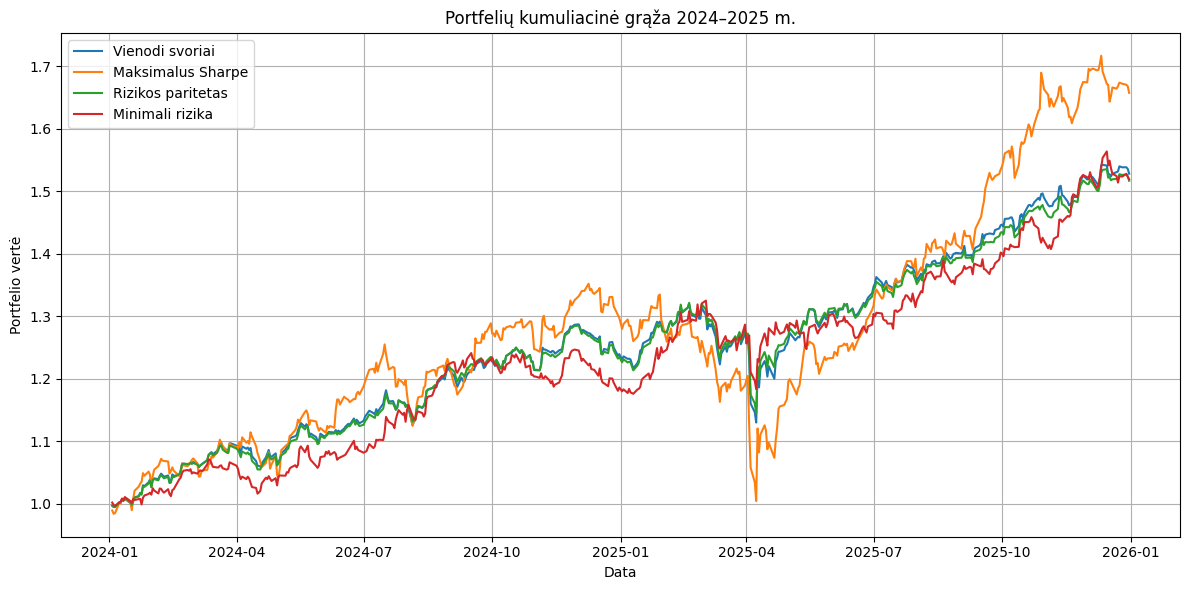

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
portfelio_grazos_vienodi = grąžos_testavimui.dot(vienodi_svoriai)
portfelio_grazos_maksimalus_sharpe = grąžos_testavimui.dot(svoriai_maksimaliam_sharpe)
portfelio_grazos_rizikos_paritetas = grąžos_testavimui.dot(svoriai_rizikos_paritetui)
portfelio_grazos_minimali_rizika = grąžos_testavimui.dot(svoriai_minimaliai_rizikai)
portfeliu_grazos = pd.DataFrame({
    "Vienodi svoriai": portfelio_grazos_vienodi,
    "Maksimalus Sharpe": portfelio_grazos_maksimalus_sharpe,
    "Rizikos paritetas": portfelio_grazos_rizikos_paritetas,
    "Minimali rizika": portfelio_grazos_minimali_rizika,
})
def metine_graza(grazos):
    return grazos.mean() * 252
def metine_rizika(grazos):
    return grazos.std() * np.sqrt(252)
def sharpe_rodiklis(grazos, nerizikinga_palukanu_norma=0.0):
    rizika = metine_rizika(grazos)
    if rizika == 0:
        return np.nan
    return (metine_graza(grazos) - nerizikinga_palukanu_norma) / rizika
def kumuliacine_graza(grazos):
    return (1 + grazos).prod() - 1
def maksimalus_nuosmukis(grazos):
    kumuliacine_reiksme = (1 + grazos).cumprod()
    einamasis_maksimumas = kumuliacine_reiksme.cummax()
    nuosmukis = kumuliacine_reiksme / einamasis_maksimumas - 1
    return nuosmukis.min()
palyginimo_lentele = pd.DataFrame({
    "Metinė grąža": portfeliu_grazos.apply(metine_graza),
    "Metinė rizika": portfeliu_grazos.apply(metine_rizika),
    "Sharpe rodiklis": portfeliu_grazos.apply(sharpe_rodiklis),
    "Kumuliacinė grąža": portfeliu_grazos.apply(kumuliacine_graza),
    "Maksimalus nuosmukis": portfeliu_grazos.apply(maksimalus_nuosmukis)
})
palyginimo_lentele = palyginimo_lentele.round(4)
print("Portfelių palyginimo lentelė (2024–2025 m.):")
print(palyginimo_lentele)
palyginimo_lentele_procentais = palyginimo_lentele.copy()
palyginimo_lentele_procentais["Metinė grąža"] = (palyginimo_lentele_procentais["Metinė grąža"] * 100).round(2)
palyginimo_lentele_procentais["Metinė rizika"] = (palyginimo_lentele_procentais["Metinė rizika"] * 100).round(2)
palyginimo_lentele_procentais["Kumuliacinė grąža"] = (palyginimo_lentele_procentais["Kumuliacinė grąža"] * 100).round(2)
palyginimo_lentele_procentais["Maksimalus nuosmukis"] = (palyginimo_lentele_procentais["Maksimalus nuosmukis"] * 100).round(2)
print("\nPortfelių palyginimo lentelė procentais (2024–2025 m.):")
print(palyginimo_lentele_procentais)
kumuliacines_reiksmes = (1 + portfeliu_grazos).cumprod()
plt.figure(figsize=(12, 6))
for stulpelis in kumuliacines_reiksmes.columns:
    plt.plot(kumuliacines_reiksmes.index, kumuliacines_reiksmes[stulpelis], label=stulpelis)
plt.title("Portfelių kumuliacinė grąža 2024–2025 m.")
plt.xlabel("Data")
plt.ylabel("Portfelio vertė")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Veiklos rodiklių lentelė:
                   Metinė grąža  Metinė rizika  Sharpe rodiklis  \
Vienodi svoriai           22.07          12.12           1.8203   
Maksimalus Sharpe         27.28          19.34           1.4101   
Rizikos paritetas         21.62          11.52           1.8770   
Minimali rizika           21.78          12.21           1.7843   

                   Kumuliacinė grąža  Maksimalus nuosmukis  
Vienodi svoriai                52.81                -14.38  
Maksimalus Sharpe              65.73                -25.71  
Rizikos paritetas              51.67                -13.40  
Minimali rizika                51.91                -10.67  

Portfelių svorių lentelė (%):
Akcija  Vienodi svoriai  Maksimalus Sharpe  Rizikos paritetas  Minimali rizika
  AAPL             10.0              34.67               7.97             0.00
   CAT             10.0              29.77               8.46             2.40
   JNJ             10.0               0.00              13.18    

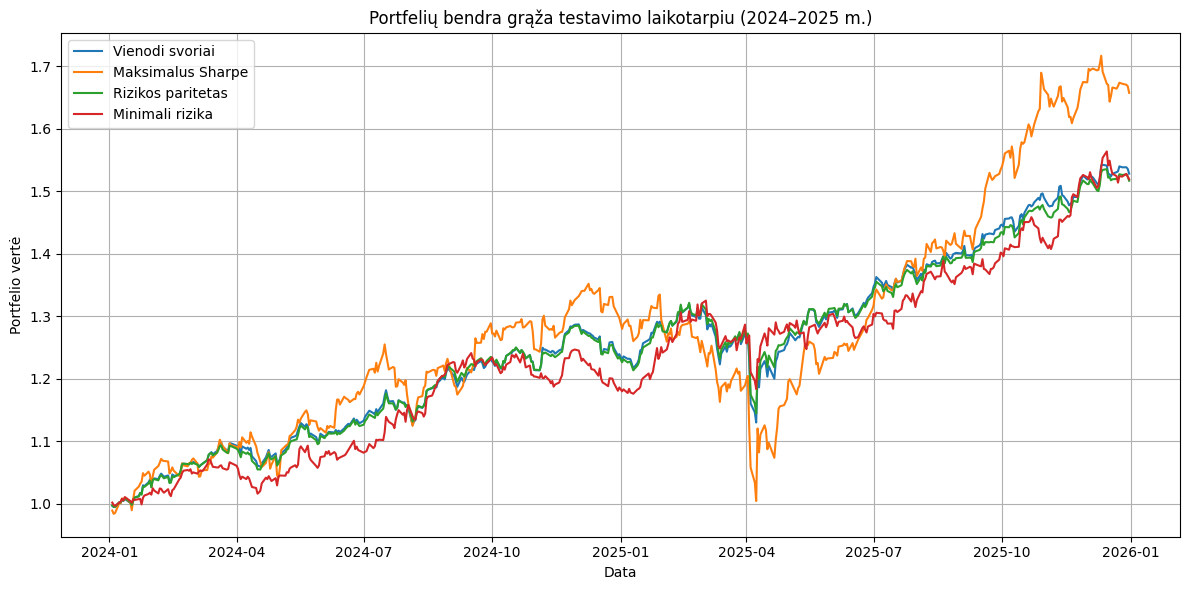

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
portfelio_grazos_vienodi = grąžos_testavimui.dot(vienodi_svoriai)
portfelio_grazos_maksimalus_sharpe = grąžos_testavimui.dot(svoriai_maksimaliam_sharpe)
portfelio_grazos_rizikos_paritetas = grąžos_testavimui.dot(svoriai_rizikos_paritetui)
portfelio_grazos_minimali_rizika = grąžos_testavimui.dot(svoriai_minimaliai_rizikai)
portfeliu_grazos = pd.DataFrame({
    "Vienodi svoriai": portfelio_grazos_vienodi,
    "Maksimalus Sharpe": portfelio_grazos_maksimalus_sharpe,
    "Rizikos paritetas": portfelio_grazos_rizikos_paritetas,
    "Minimali rizika": portfelio_grazos_minimali_rizika,
})
def metine_graza(grazos):
    return grazos.mean() * 252
def metine_rizika(grazos):
    return grazos.std() * np.sqrt(252)
def sharpe_rodiklis(grazos, nerizikinga_palukanu_norma=0.0):
    rizika = metine_rizika(grazos)
    if rizika == 0:
        return np.nan
    return (metine_graza(grazos) - nerizikinga_palukanu_norma) / rizika
def kumuliacine_graza(grazos):
    return (1 + grazos).prod() - 1
def maksimalus_nuosmukis(grazos):
    kumuliacine_reiksme = (1 + grazos).cumprod()
    einamasis_maksimumas = kumuliacine_reiksme.cummax()
    nuosmukis = kumuliacine_reiksme / einamasis_maksimumas - 1
    return nuosmukis.min()
veiklos_rodikliu_lentele = pd.DataFrame({
    "Metinė grąža": portfeliu_grazos.apply(metine_graza),
    "Metinė rizika": portfeliu_grazos.apply(metine_rizika),
    "Sharpe rodiklis": portfeliu_grazos.apply(sharpe_rodiklis),
    "Kumuliacinė grąža": portfeliu_grazos.apply(kumuliacine_graza),
    "Maksimalus nuosmukis": portfeliu_grazos.apply(maksimalus_nuosmukis)
}).round(4)

veiklos_rodikliu_lentele_procentais = veiklos_rodikliu_lentele.copy()
veiklos_rodikliu_lentele_procentais["Metinė grąža"] = (veiklos_rodikliu_lentele_procentais["Metinė grąža"] * 100).round(2)
veiklos_rodikliu_lentele_procentais["Metinė rizika"] = (veiklos_rodikliu_lentele_procentais["Metinė rizika"] * 100).round(2)
veiklos_rodikliu_lentele_procentais["Kumuliacinė grąža"] = (veiklos_rodikliu_lentele_procentais["Kumuliacinė grąža"] * 100).round(2)
veiklos_rodikliu_lentele_procentais["Maksimalus nuosmukis"] = (veiklos_rodikliu_lentele_procentais["Maksimalus nuosmukis"] * 100).round(2)
svoriu_lentele = pd.DataFrame({
    "Akcija": grąžos_mokymui.columns,
    "Vienodi svoriai": vienodi_svoriai,
    "Maksimalus Sharpe": svoriai_maksimaliam_sharpe,
    "Rizikos paritetas": svoriai_rizikos_paritetui,
    "Minimali rizika": svoriai_minimaliai_rizikai,
})
for stulpelis in svoriu_lentele.columns[1:]:
    svoriu_lentele[stulpelis] = (svoriu_lentele[stulpelis] * 100).round(2)
print("Veiklos rodiklių lentelė:")
print(veiklos_rodikliu_lentele_procentais)
print("\nPortfelių svorių lentelė (%):")
print(svoriu_lentele.to_string(index=False))
kumuliacines_reiksmes = (1 + portfeliu_grazos).cumprod()
plt.figure(figsize=(12, 6))
for stulpelis in kumuliacines_reiksmes.columns:
    plt.plot(kumuliacines_reiksmes.index, kumuliacines_reiksmes[stulpelis], label=stulpelis)
plt.title("Portfelių bendra grąža testavimo laikotarpiu (2024–2025 m.)")
plt.xlabel("Data")
plt.ylabel("Portfelio vertė")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [20]:
import pandas as pd
import numpy as np
def maksimalus_nuosmukis_is_kainu(kainu_eilute):
    kaupiamasis_maksimumas = kainu_eilute.cummax()
    nuosmukis = kainu_eilute / kaupiamasis_maksimumas - 1
    return nuosmukis.min()
metine_vidutine_graza = grąžos_mokymui.mean() * 252
metine_rizika = grąžos_mokymui.std() * np.sqrt(252)
maksimalus_nuosmukis = kainos_mokymui.apply(maksimalus_nuosmukis_is_kainu)
akciju_statistika = pd.DataFrame({
    "Metinė vidutinė grąža": metine_vidutine_graza,
    "Metinė rizika": metine_rizika,
    "Maksimalus nuosmukis": maksimalus_nuosmukis
})
akciju_statistika_procentais = akciju_statistika.copy()
akciju_statistika_procentais["Metinė vidutinė grąža"] = (akciju_statistika_procentais["Metinė vidutinė grąža"] * 100).round(2)
akciju_statistika_procentais["Metinė rizika"] = (akciju_statistika_procentais["Metinė rizika"] * 100).round(2)
akciju_statistika_procentais["Maksimalus nuosmukis"] = (akciju_statistika_procentais["Maksimalus nuosmukis"] * 100).round(2)
akciju_statistika_procentais = akciju_statistika_procentais.sort_values(
    by="Metinė vidutinė grąža", ascending=False)
print("Atrinktų akcijų statistinės charakteristikos mokymo laikotarpiu:")
print(akciju_statistika_procentais)

Atrinktų akcijų statistinės charakteristikos mokymo laikotarpiu:
        Metinė vidutinė grąža  Metinė rizika  Maksimalus nuosmukis
Ticker                                                            
AAPL                    29.90          33.57                -31.43
MSFT                    27.58          32.62                -37.15
CAT                     25.06          33.93                -38.55
XOM                     20.79          37.23                -55.00
JPM                     13.62          34.42                -43.63
V                       12.94          30.02                -36.36
WMT                     11.44          23.61                -25.74
PG                       9.24          22.17                -23.77
KO                       7.38          22.37                -36.99
JNJ                      6.60          20.64                -27.37
